# California Housing Prices Prediction with Machine Learning

### Exploratory Data Analysis (EDA)

This notebook performs an initial exploration of the **California Housing dataset**.  
The goal is to understand the structure, quality, and statistical properties of the data before applying any preprocessing or machine learning techniques.

Exploratory Data Analysis is a crucial step in any machine learning project, as it helps identify:

- Data types and feature structure
- Missing values
- Distribution of variables
- Potential outliers
- Relationships between variables

The insights obtained in this phase will guide the preprocessing and modeling steps in later notebooks.

### 1. Importing Libraries and Loading the Dataset

We begin by importing the libraries required for data manipulation, visualization, and analysis.

The dataset used in this project is the **California Housing dataset** (housing.csv), which contains information about housing districts in California derived from the 1990 census.

Each row represents a district and includes features such as:

- Median income
- Housing median age
- Average number of rooms
- Population
- Geographic location (latitude and longitude)

The target variable is:

**`median_house_value`** – the median house price for households within a district.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("housing.csv")
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

### 2. Initial Data Inspection

Before performing any transformations, we first inspect the dataset to understand:

- The number of observations and features
- Data types of each column
- A sample of the dataset

This helps verify that the dataset has been loaded correctly and provides an overview of its structure.

We observe all data is numerical except `"ocean_proximity"`, which is categorical.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [18]:
#Check the different values the categorical variable has.

df["ocean_proximity"].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [19]:
#First rows of the dataset.

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 3. Missing Values Analysis

We check whether any features contain missing values and assess how significant they are.

If missing data is present, we will later decide whether to:

- Remove affected rows
- Impute missing values
- Apply more advanced preprocessing techniques

We observe there is some missing data (207 values) in the `"total_bedrooms"` column.

In [20]:
#Check the total missing values by column.

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### 4. Descriptive Statistics

We compute summary statistics to better understand the distribution of numerical features.

This includes metrics such as:

- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

These statistics provide a first indication of scale differences, skewness, and potential outliers.

In [21]:
df["median_house_value"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [22]:
df["median_income"].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

### 5. Feature Distributions and Correlation Analysis

Visualizing feature distributions helps identify:

- Skewed variables
- Potential outliers
- Non-linear patterns

Histograms and density plots are useful tools to understand the distribution of both numerical and categorical variables.

We also explore correlations between numerical variables, particularly with the target variable **`median_house_value`**. This helps identify which features may have the strongest predictive power.

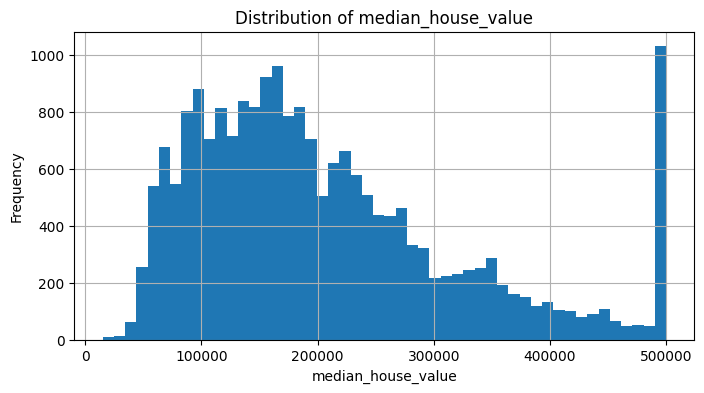

In [23]:
#Histogram of median_house_value.

df["median_house_value"].hist(bins=50, figsize=(8, 4))
plt.title("Distribution of median_house_value")
plt.xlabel("median_house_value")
plt.ylabel("Frequency")
plt.show()

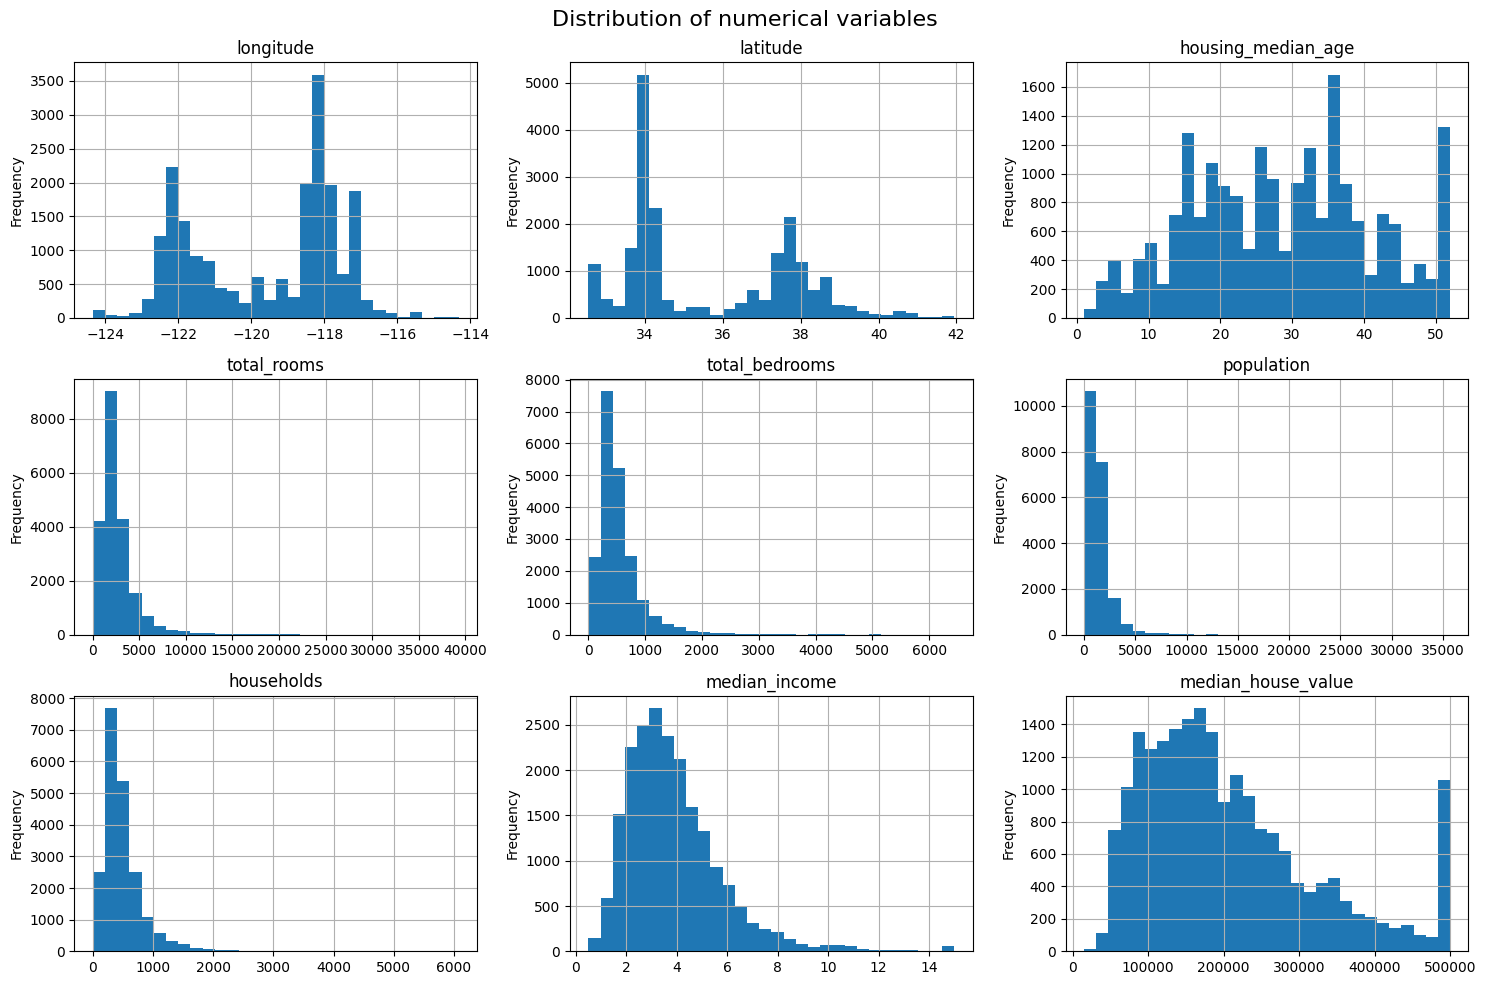

In [24]:
#Histograms of numerical variables.

axes = df.hist(bins=30, figsize=(15, 10))
for ax in axes.flatten():
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of numerical variables", fontsize=16)

plt.tight_layout()
plt.show()

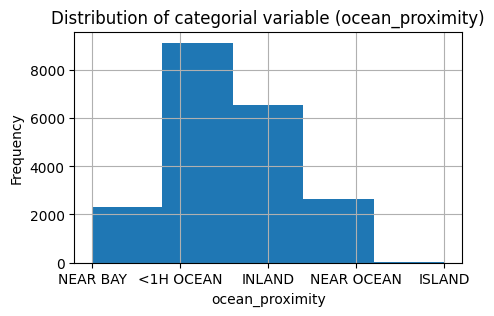

In [25]:
#Histogram of the categorical variable.

df["ocean_proximity"].hist(bins=5, figsize=(5, 3))
plt.title("Distribution of categorial variable (ocean_proximity)")
plt.xlabel("ocean_proximity")
plt.ylabel("Frequency")
plt.show()

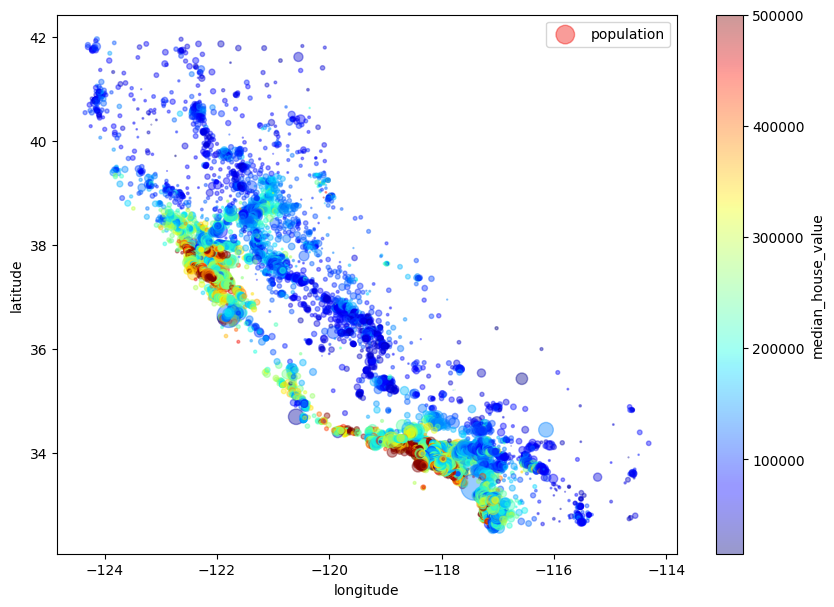

In [26]:
#Representation of housing by position (lat+lon), median value and population. 

df.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=df["population"] / 100,
    label="population",
    figsize=(10, 7),
    c="median_house_value",
    cmap="jet",
    colorbar=True
)
plt.legend()
plt.show()

<Axes: >

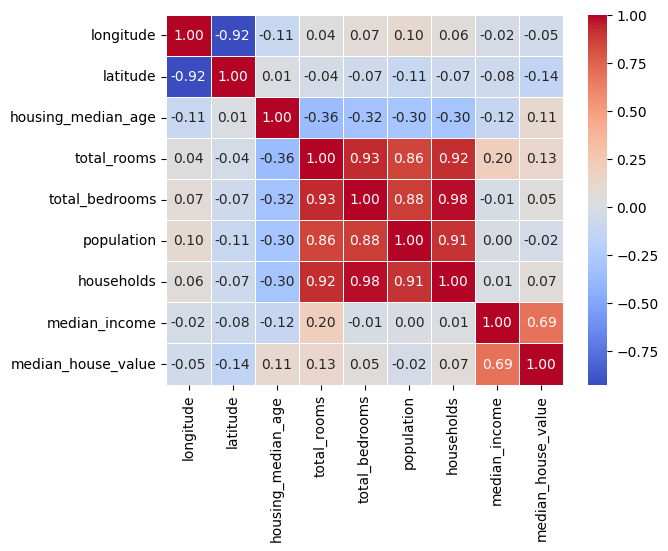

In [27]:
# Correlation matrix (heatmap) on the numeric variables.

corr = df.select_dtypes('number').corr()

sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",   
    linewidths=0.5     
)

### Key Findings from the Exploratory Analysis

The exploratory analysis reveals several important characteristics of the dataset:

- The dataset contains 207 missing values in the `total_bedrooms` column, which will need to be handled during preprocessing.
- The feature `ocean_proximity` is categorical, meaning it will require encoding before being used in machine learning models.
- Geographic features such as latitude and longitude may capture spatial patterns in housing prices.
- `"median_income"` and `"median_house_value"` show strong right-skewed distributions.
- The feature `median_income` shows the strongest correlation with the target variable `median_house_value`, indicating it may be one of the most informative predictors.

These observations will guide the preprocessing and feature engineering steps in the next stage of the project.

#### Next Steps

Based on the findings from the exploratory data analysis, the next notebook will focus on:

- Handling missing values
- Encoding categorical variables
- Preparing the dataset for machine learning models